# Import + Mutual Information Matrix Analysis

This notebook imports the CSD/GCaMP waveform feature CSV and computes **mutual information matrices** separately for each animal/stage/condition block.

Goal:

- Parse metadata from the first column.
- Keep only individual cell/event rows.
- Compute mutual information among:
  - amplitude
  - FWHM
  - prominence
  - AUC
  - rise
  - decay
  - duration
- Save one MI matrix and heatmap per animal/block.
- Compare post-CSD vs pre-CSD MI structure within each animal.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

data_path = Path("../data/240619_Seizures_plotData.csv")

# Use this instead only if your local filename includes (1):
# data_path = Path("../data/240619_Seizures_plotData(1).csv")

output_dir = Path("../outputs/mutual_information_analysis")
matrix_dir = output_dir / "mi_matrices"
fig_dir = output_dir / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
matrix_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

print("Input file:", data_path)

Input file: ../data/240619_Seizures_plotData.csv


In [2]:
raw = pd.read_csv(data_path)

print("Raw shape:", raw.shape)
display(raw.head(20))
print(raw.columns.tolist())

Raw shape: (673, 8)


,Unnamed: 0,amplitude,FWHM,prominence,AUC,rise,decay,duration
0,M15 pre CSD,0.189530797,11.92850904,0.131078746,3.413801929,27.79166667,15.20833333,43
1,Sham,0.30082629,21.60212123,0.158804082,6.627933861,11.64516129,17.35483871,29
2,NaN,0.302680952,33.07596846,0.141533188,6.985216869,10.86666667,18.13333333,29
3,NaN,0.371592378,23.43480083,0.155422561,11.69008973,16.70588235,23.29411765,40
4,total seizures = 32,0.315064949,33.65933818,0.138499456,6.304591116,12.7826087,10.2173913,23
5,NaN,0.337296866,67.07371877,0.155679518,6.692575354,11.13636364,10.86363636,22
6,3.48/min,0.392072743,79.62663722,0.143255025,11.95135478,16.025,17.975,34
7,NaN,0.362337647,88.32437392,0.183586804,11.26992345,23.44871795,11.55128205,35
8,NaN,0.299252887,72.90387218,0.132349996,6.030344907,9.695652174,15.30434783,25
9,NaN,0.473439306,15.43806631,0.12893423,11.67806721,20.28571429,9.714285714,30


['Unnamed: 0', 'amplitude', 'FWHM ', 'prominence', 'AUC', 'rise', 'decay', 'duration']


In [3]:
raw = raw.rename(
    columns={
        "Unnamed: 0": "label",
        "FWHM ": "FWHM"
    }
)

feature_cols = [
    "amplitude",
    "FWHM",
    "prominence",
    "AUC",
    "rise",
    "decay",
    "duration"
]

for col in feature_cols:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

animal_pattern = re.compile(
    r"^(M\d+)\s+(pre|post)\s+CSD$",
    re.IGNORECASE
)

current_animal = None
current_stage = None
current_condition = None
current_total_seizures = np.nan
current_rate_per_min = np.nan

event_rows = []
metadata_rows = []

for idx, row in raw.iterrows():

    label = row["label"]
    label_str = str(label).strip() if pd.notna(label) else ""

    animal_match = animal_pattern.match(label_str)

    if animal_match:
        current_animal = animal_match.group(1)
        current_stage = animal_match.group(2).lower() + "_CSD"
        current_condition = None
        current_total_seizures = np.nan
        current_rate_per_min = np.nan

        metadata_rows.append({
            "source_row": idx,
            "animal": current_animal,
            "stage": current_stage,
            "condition": current_condition,
            "metadata_type": "animal_stage",
            "metadata_value": label_str
        })
        continue

    if label_str.lower() in ["sham", "cci"]:
        current_condition = "CCI" if label_str.lower() == "cci" else "Sham"

        metadata_rows.append({
            "source_row": idx,
            "animal": current_animal,
            "stage": current_stage,
            "condition": current_condition,
            "metadata_type": "condition",
            "metadata_value": label_str
        })
        continue

    if label_str.lower().startswith("total seizures"):
        match = re.search(r"(\d+)", label_str)
        if match:
            current_total_seizures = int(match.group(1))
        continue

    if "/min" in label_str.lower():
        match = re.search(r"([0-9]*\.?[0-9]+)", label_str)
        if match:
            current_rate_per_min = float(match.group(1))
        continue

    if label_str.upper() in ["AVG", "SEM"]:
        continue

    if label_str and row[feature_cols].notna().sum() == 0:
        metadata_rows.append({
            "source_row": idx,
            "animal": current_animal,
            "stage": current_stage,
            "condition": current_condition,
            "metadata_type": "note",
            "metadata_value": label_str
        })
        continue

    if row[feature_cols].notna().sum() > 0 and current_animal is not None:

        event = {
            "source_row": idx,
            "event_id": len(event_rows),
            "animal": current_animal,
            "condition": current_condition if current_condition is not None else "Unknown",
            "stage": current_stage,
            "block": f"{current_animal}_{current_stage}_{current_condition if current_condition is not None else 'Unknown'}",
            "total_seizures_block": current_total_seizures,
            "rate_per_min_block": current_rate_per_min,
        }

        for col in feature_cols:
            event[col] = row[col]

        event_rows.append(event)

events = pd.DataFrame(event_rows)
metadata = pd.DataFrame(metadata_rows)

print("Clean event table:", events.shape)
display(events.head())
display(events.tail())

print("Events per animal/stage/condition:")
display(
    events
    .groupby(["animal", "stage", "condition"])
    .size()
    .reset_index(name="n_events")
)

events.to_csv(output_dir / "csd_waveform_events_clean.csv", index=False)
metadata.to_csv(output_dir / "csd_waveform_metadata_rows.csv", index=False)

Clean event table: (527, 15)


,source_row,event_id,animal,condition,stage,block,total_seizures_block,rate_per_min_block,amplitude,FWHM,prominence,AUC,rise,decay,duration
0,2,0,M15,Sham,pre_CSD,M15_pre_CSD_Sham,NaN,NaN,0.302681,33.075968,0.141533,6.985217,10.866667,18.133333,29.0
1,3,1,M15,Sham,pre_CSD,M15_pre_CSD_Sham,NaN,NaN,0.371592,23.434801,0.155423,11.690090,16.705882,23.294118,40.0
2,5,2,M15,Sham,pre_CSD,M15_pre_CSD_Sham,32.0,NaN,0.337297,67.073719,0.155680,6.692575,11.136364,10.863636,22.0
3,7,3,M15,Sham,pre_CSD,M15_pre_CSD_Sham,32.0,3.48,0.362338,88.324374,0.183587,11.269923,23.448718,11.551282,35.0
4,8,4,M15,Sham,pre_CSD,M15_pre_CSD_Sham,32.0,3.48,0.299253,72.903872,0.132350,6.030345,9.695652,15.304348,25.0


,source_row,event_id,animal,condition,stage,block,total_seizures_block,rate_per_min_block,amplitude,FWHM,prominence,AUC,rise,decay,duration
522,665,522,M18,Unknown,post_CSD,M18_post_CSD_Unknown,NaN,5.86,0.162366,15.874355,0.101108,4.809779,24.240566,18.759434,43.0
523,666,523,M18,Unknown,post_CSD,M18_post_CSD_Unknown,NaN,5.86,0.151890,25.180128,0.084586,5.778130,34.543860,16.456140,51.0
524,667,524,M18,Unknown,post_CSD,M18_post_CSD_Unknown,NaN,5.86,0.154753,8.753580,0.084509,4.117778,15.301587,23.698413,39.0
525,668,525,M18,Unknown,post_CSD,M18_post_CSD_Unknown,NaN,5.86,0.155280,10.670636,0.069283,2.107661,8.281690,8.718310,17.0
526,669,526,M18,Unknown,post_CSD,M18_post_CSD_Unknown,NaN,5.86,0.200549,16.354656,0.140859,4.591752,21.525316,12.474684,34.0


Events per animal/stage/condition:


,animal,stage,condition,n_events
0,M13,post_CSD,CCI,89
1,M13,pre_CSD,CCI,40
2,M15,post_CSD,Sham,49
3,M15,pre_CSD,Sham,28
4,M16,post_CSD,CCI,62
5,M16,pre_CSD,CCI,30
6,M18,post_CSD,Unknown,107
7,M18,pre_CSD,Unknown,17
8,M19,post_CSD,CCI,26
9,M19,pre_CSD,CCI,26


In [10]:
def compute_mutual_information_matrix(data, feature_cols, random_state=42):
    clean_data = data[feature_cols].dropna().copy()

    if clean_data.shape[0] < 5:
        return None

    X = StandardScaler().fit_transform(clean_data.values)

    n_features = len(feature_cols)

    mi_matrix = np.zeros((n_features, n_features), dtype=float)

    for i in range(n_features):
        for j in range(n_features):

            if i == j:
                mi_matrix[i, j] = 0.0
            else:
                mi_value = mutual_info_regression(
                    X[:, [i]],
                    X[:, j],
                    random_state=random_state
                )[0]

                mi_matrix[i, j] = mi_value

    mi_matrix = (mi_matrix + mi_matrix.T) / 2

    return pd.DataFrame(
        mi_matrix,
        index=feature_cols,
        columns=feature_cols
    )


def plot_mi_heatmap(mi_df, title, output_path):

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(
        mi_df.values,
        cmap="viridis"
    )

    ax.set_xticks(np.arange(len(mi_df.columns)))
    ax.set_yticks(np.arange(len(mi_df.index)))

    ax.set_xticklabels(
        mi_df.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(mi_df.index)

    max_value = mi_df.values.max()

    for i in range(mi_df.shape[0]):
        for j in range(mi_df.shape[1]):

            value = mi_df.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > max_value / 2 else "black"
            )

    ax.set_title(title)

    fig.colorbar(
        im,
        ax=ax,
        label="Mutual information"
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    plt.show()
    # plt.close(fig)

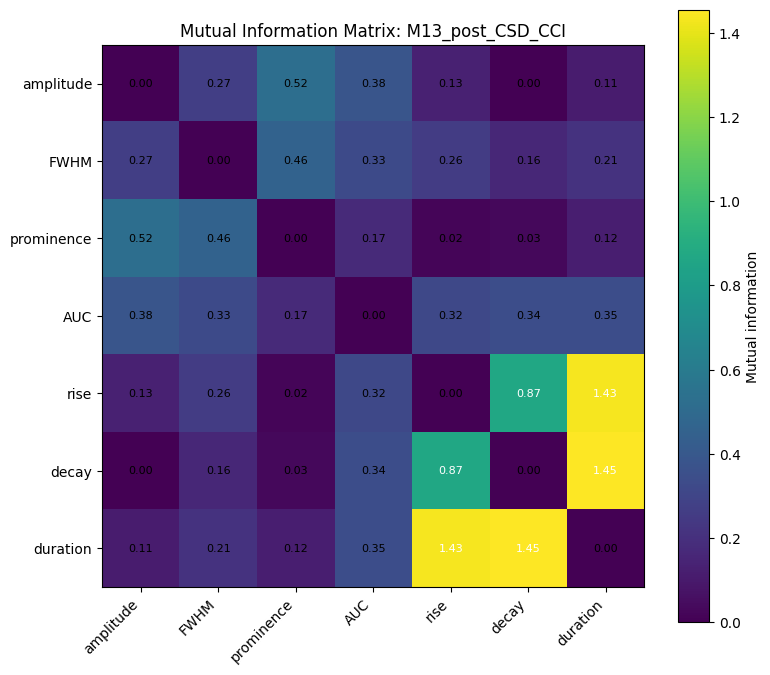

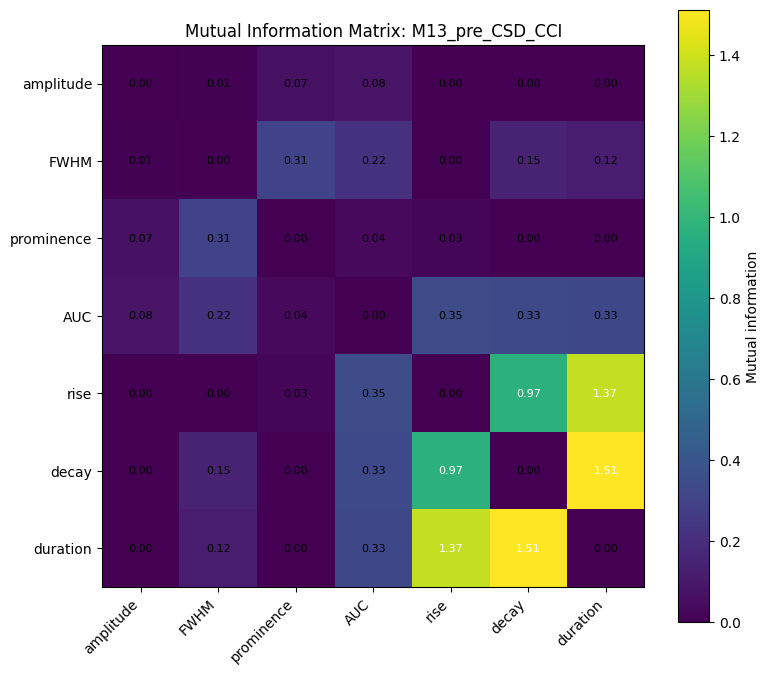

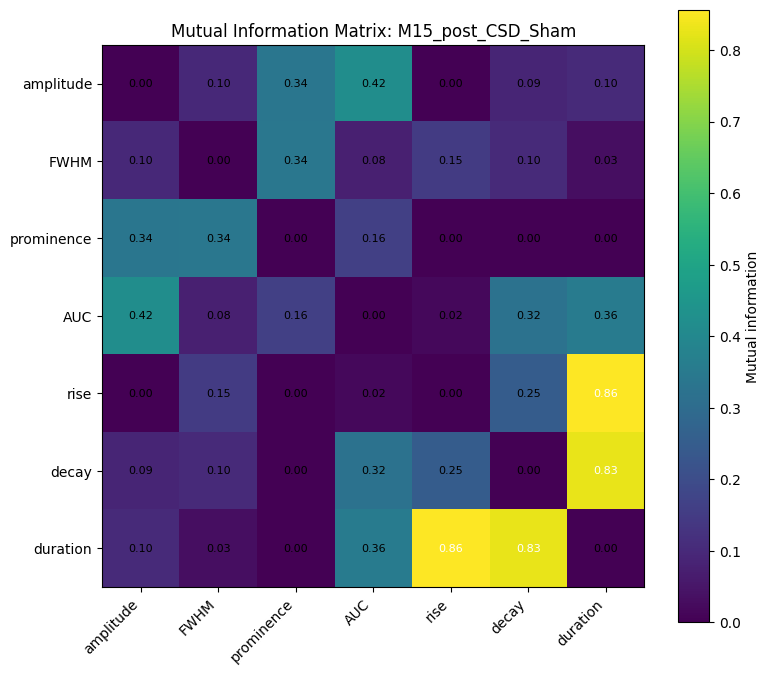

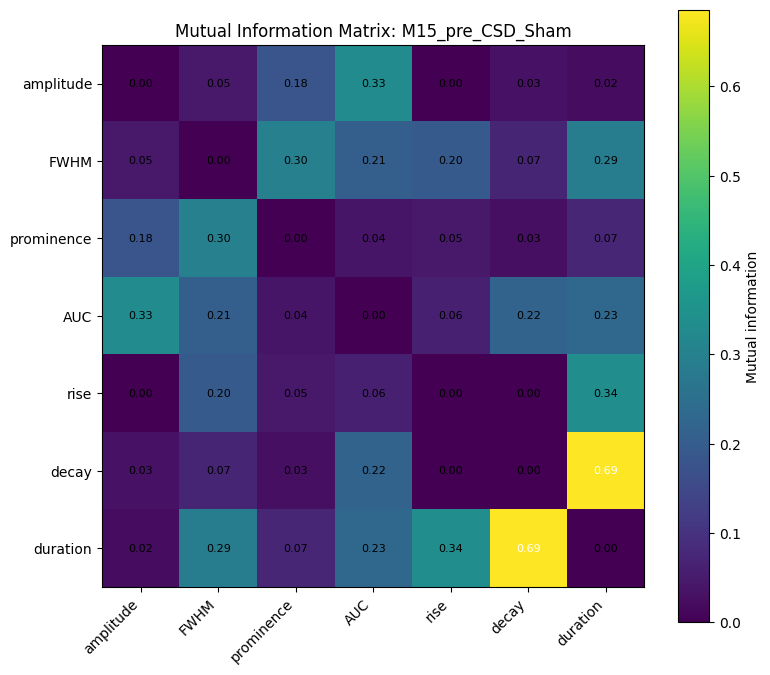

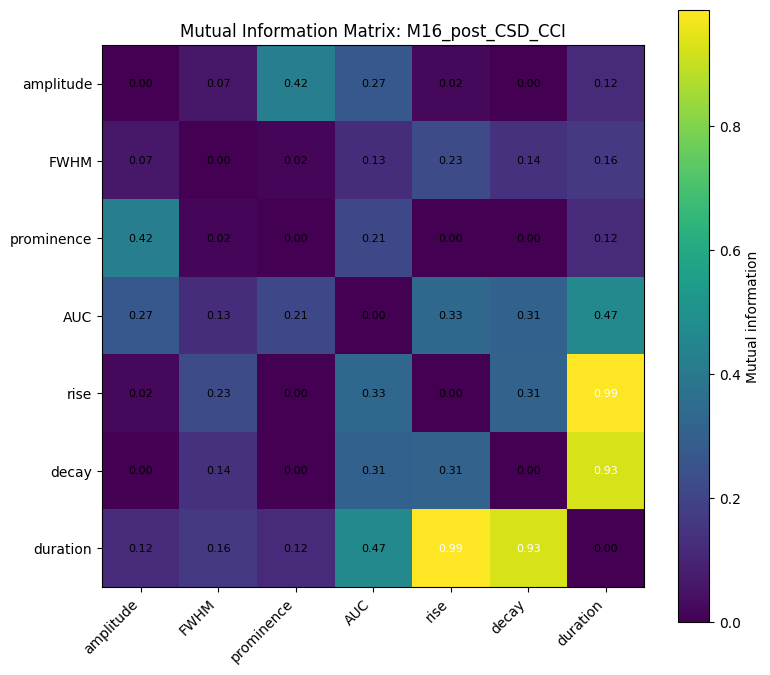

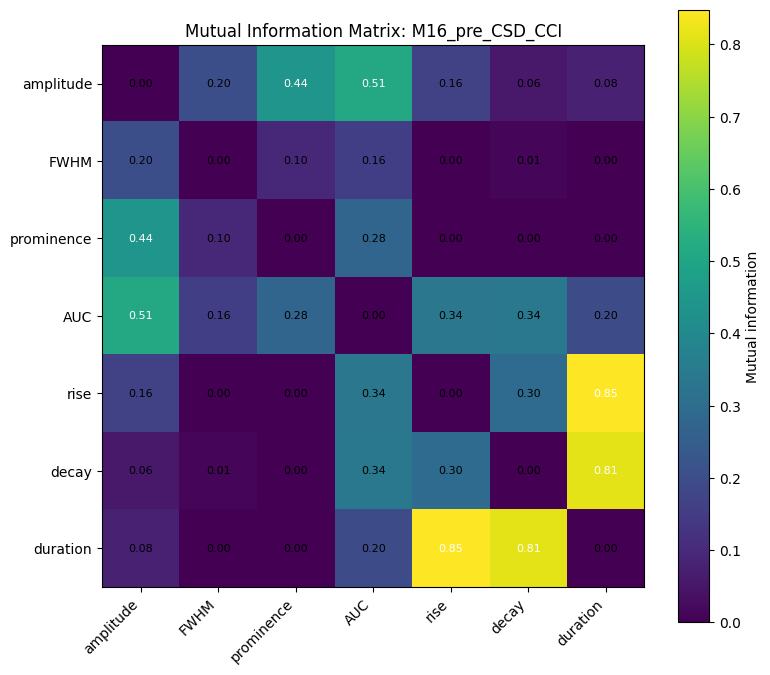

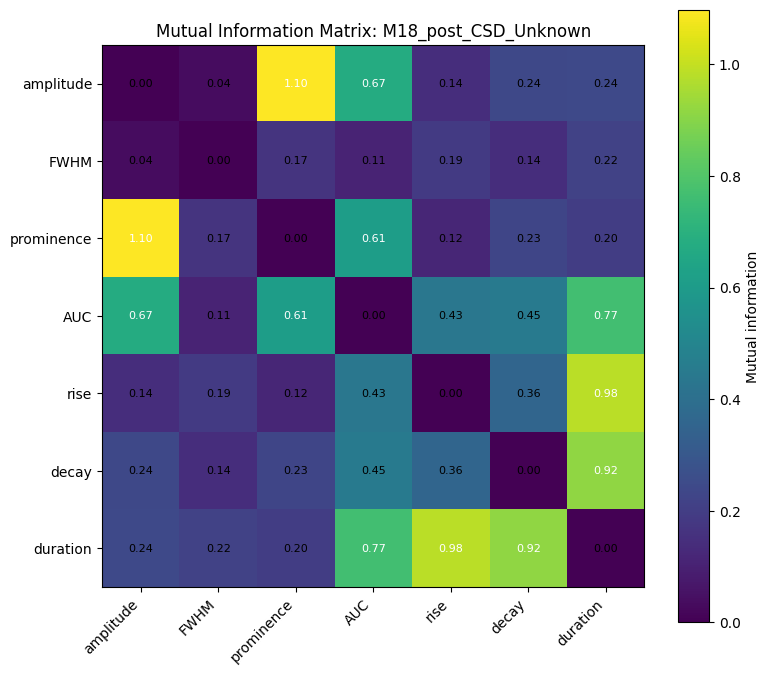

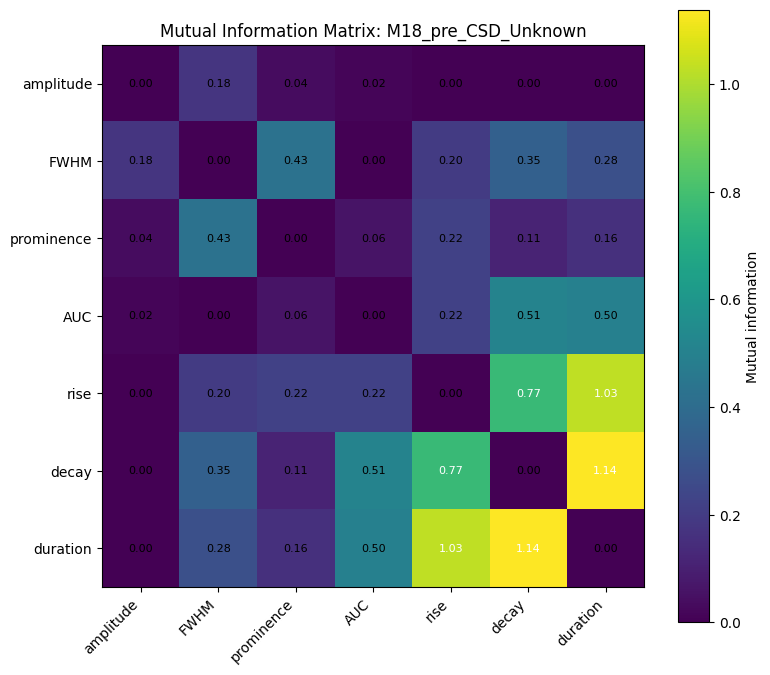

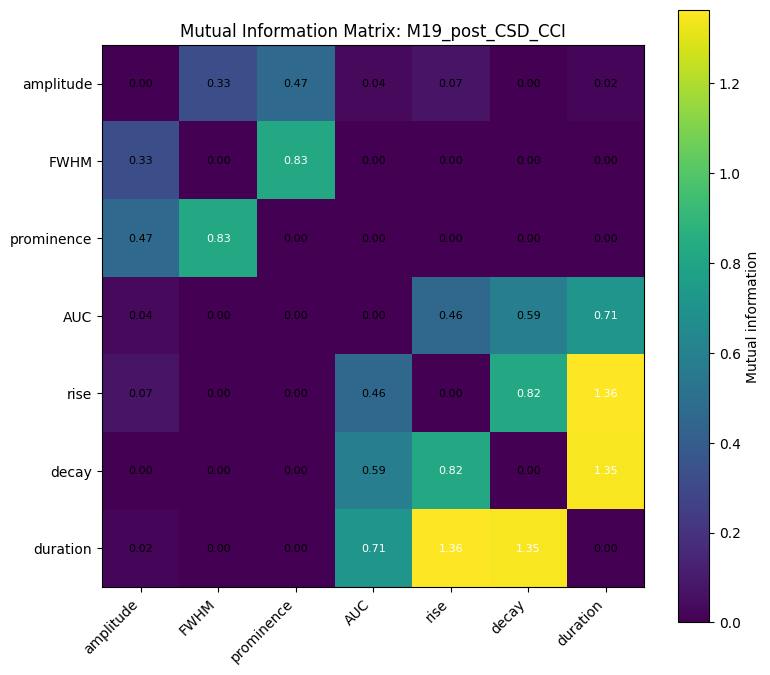

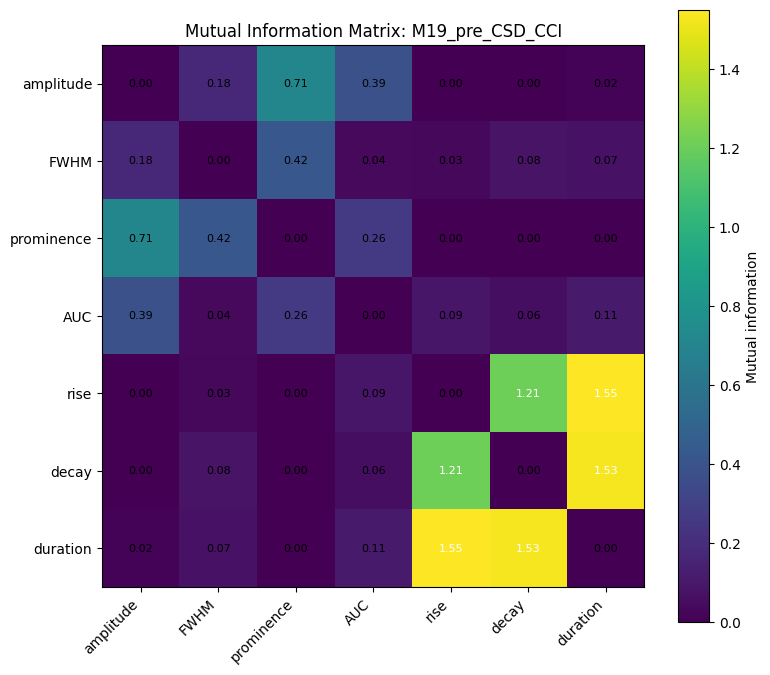

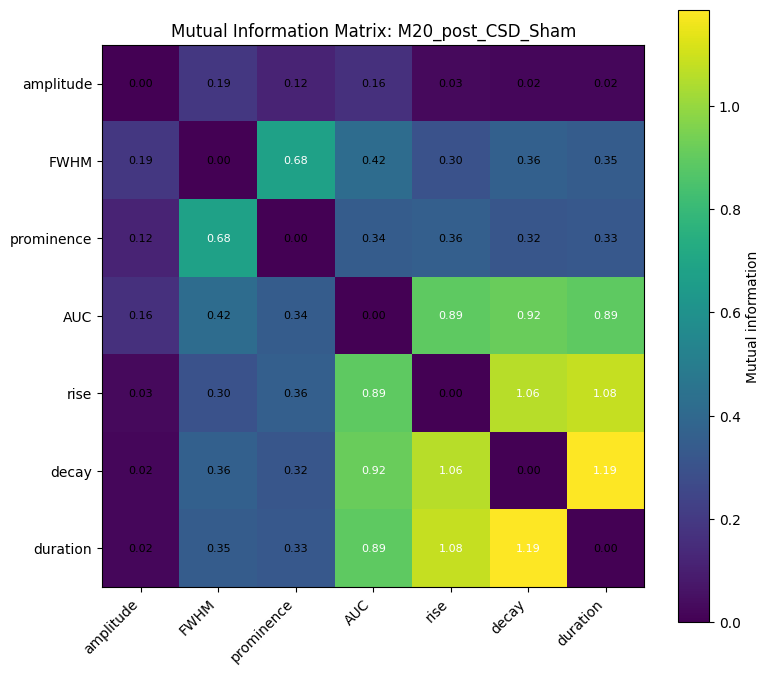

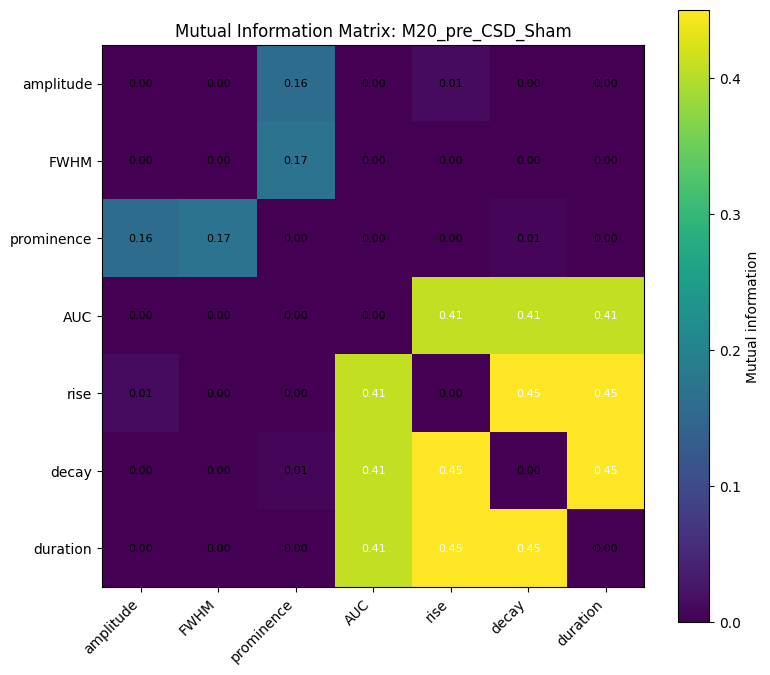

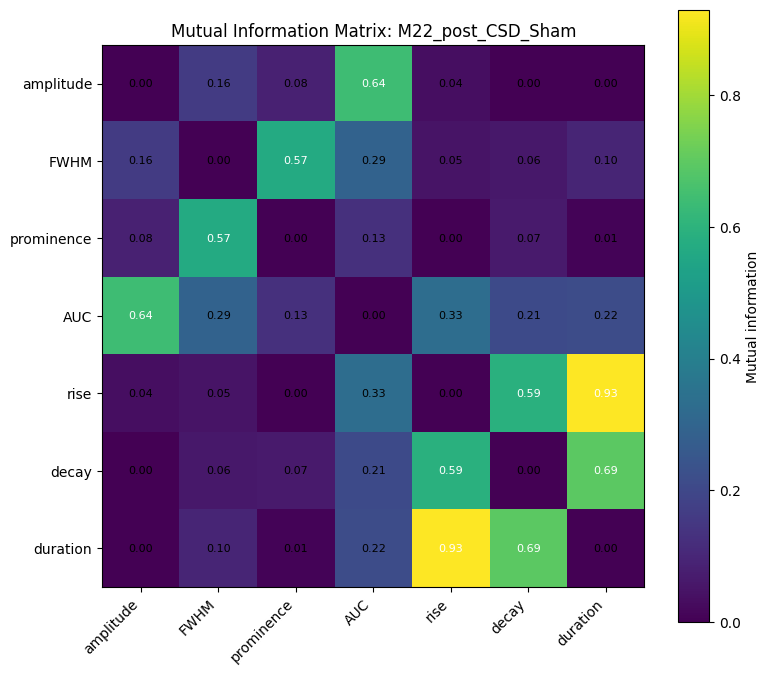

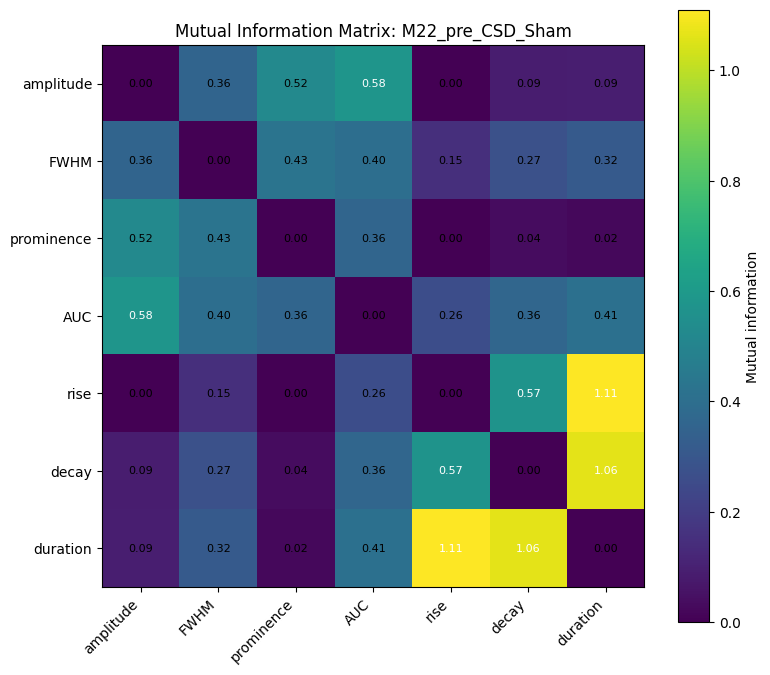

,animal,stage,condition,block,feature_a,feature_b,mutual_information,n_events
208,M19,pre_CSD,CCI,M19_pre_CSD_CCI,rise,duration,1.551703,26
209,M19,pre_CSD,CCI,M19_pre_CSD_CCI,decay,duration,1.527771,26
41,M13,pre_CSD,CCI,M13_pre_CSD_CCI,decay,duration,1.511817,40
20,M13,post_CSD,CCI,M13_post_CSD_CCI,decay,duration,1.454692,89
19,M13,post_CSD,CCI,M13_post_CSD_CCI,rise,duration,1.433768,89
40,M13,pre_CSD,CCI,M13_pre_CSD_CCI,rise,duration,1.370527,40
187,M19,post_CSD,CCI,M19_post_CSD_CCI,rise,duration,1.364264,26
188,M19,post_CSD,CCI,M19_post_CSD_CCI,decay,duration,1.352405,26
207,M19,pre_CSD,CCI,M19_pre_CSD_CCI,rise,decay,1.210659,26
230,M20,post_CSD,Sham,M20_post_CSD_Sham,decay,duration,1.186544,13


In [5]:
mi_summary_rows = []
mi_matrices = {}

for group_key, group_df in events.groupby(["animal", "stage", "condition"]):

    animal, stage, condition = group_key
    block_name = f"{animal}_{stage}_{condition}"

    mi_df = compute_mutual_information_matrix(
        group_df,
        feature_cols
    )

    if mi_df is None:
        print("Skipping, too few rows:", block_name)
        continue

    mi_matrices[block_name] = mi_df

    csv_path = matrix_dir / f"{block_name}_mutual_information_matrix.csv"
    fig_path = fig_dir / f"{block_name}_mutual_information_heatmap.tiff"

    mi_df.to_csv(csv_path)

    plot_mi_heatmap(
        mi_df,
        title=f"Mutual Information Matrix: {block_name}",
        output_path=fig_path
    )

    for i, feature_a in enumerate(feature_cols):
        for j, feature_b in enumerate(feature_cols):

            if j <= i:
                continue

            mi_summary_rows.append({
                "animal": animal,
                "stage": stage,
                "condition": condition,
                "block": block_name,
                "feature_a": feature_a,
                "feature_b": feature_b,
                "mutual_information": mi_df.loc[feature_a, feature_b],
                "n_events": group_df[feature_cols].dropna().shape[0]
            })

mi_summary = pd.DataFrame(mi_summary_rows)

mi_summary.to_csv(
    output_dir / "pairwise_mutual_information_summary.csv",
    index=False
)

display(
    mi_summary
    .sort_values("mutual_information", ascending=False)
    .head(20)
)

In [6]:
top_interactions = (
    mi_summary
    .sort_values(
        ["block", "mutual_information"],
        ascending=[True, False]
    )
    .groupby("block")
    .head(5)
    .reset_index(drop=True)
)

top_interactions.to_csv(
    output_dir / "top_mutual_information_interactions_by_block.csv",
    index=False
)

display(top_interactions)

,animal,stage,condition,block,feature_a,feature_b,mutual_information,n_events
0,M13,post_CSD,CCI,M13_post_CSD_CCI,decay,duration,1.454692,89
1,M13,post_CSD,CCI,M13_post_CSD_CCI,rise,duration,1.433768,89
2,M13,post_CSD,CCI,M13_post_CSD_CCI,rise,decay,0.868192,89
3,M13,post_CSD,CCI,M13_post_CSD_CCI,amplitude,prominence,0.524289,89
4,M13,post_CSD,CCI,M13_post_CSD_CCI,FWHM,prominence,0.457090,89
...,...,...,...,...,...,...,...,...
65,M22,pre_CSD,Sham,M22_pre_CSD_Sham,rise,duration,1.109721,23
66,M22,pre_CSD,Sham,M22_pre_CSD_Sham,decay,duration,1.064863,23
67,M22,pre_CSD,Sham,M22_pre_CSD_Sham,amplitude,AUC,0.580214,23
68,M22,pre_CSD,Sham,M22_pre_CSD_Sham,rise,decay,0.572096,23


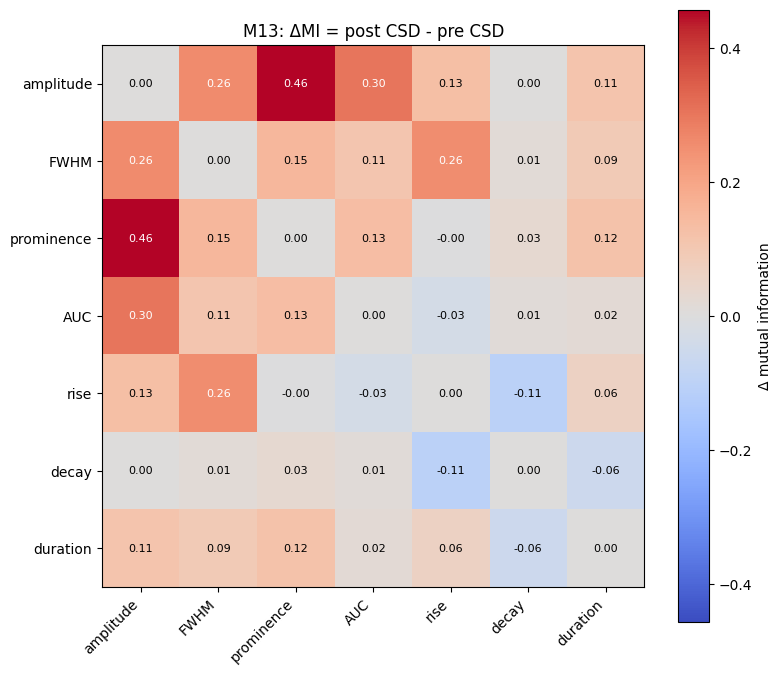

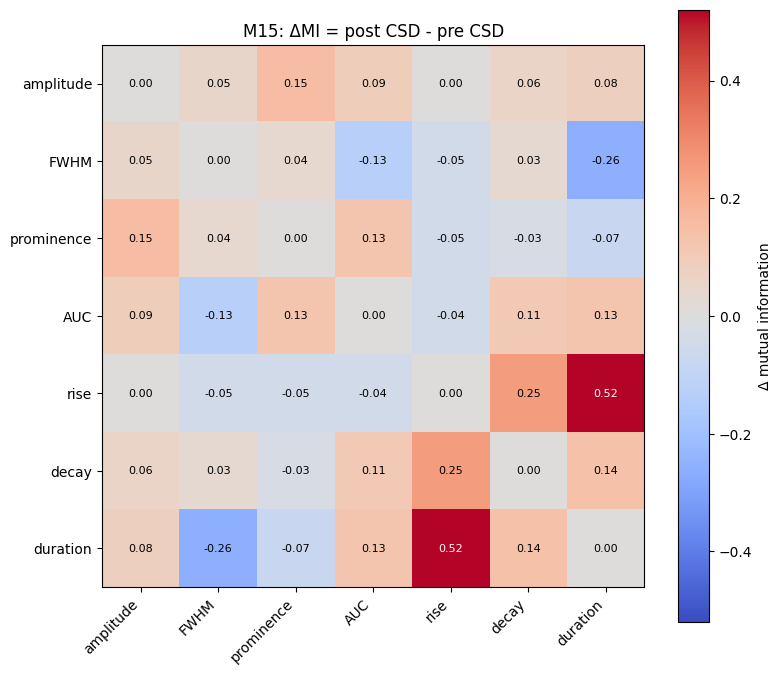

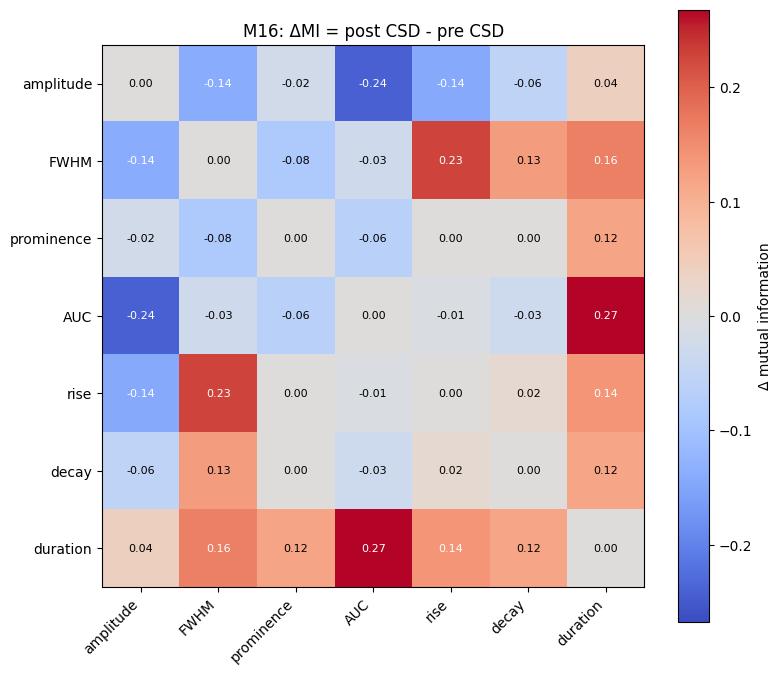

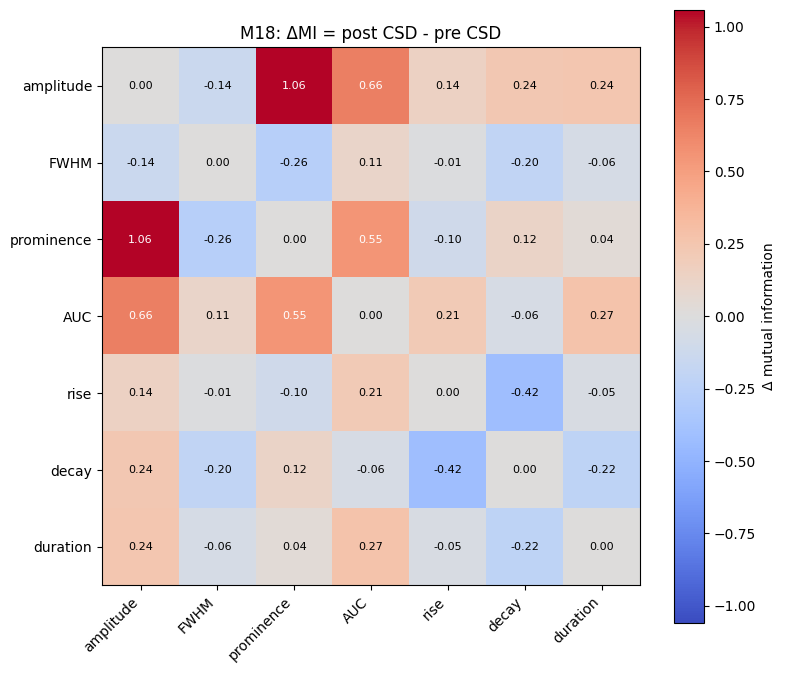

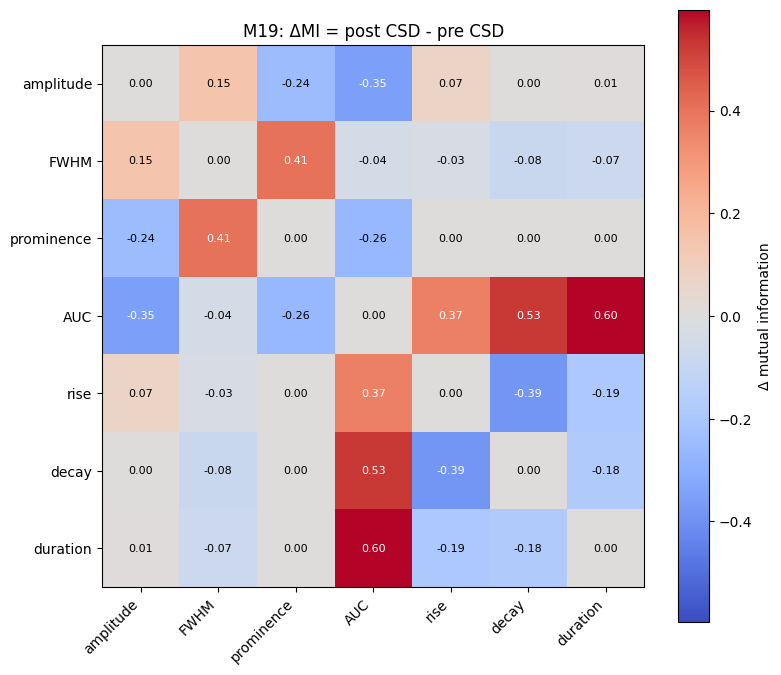

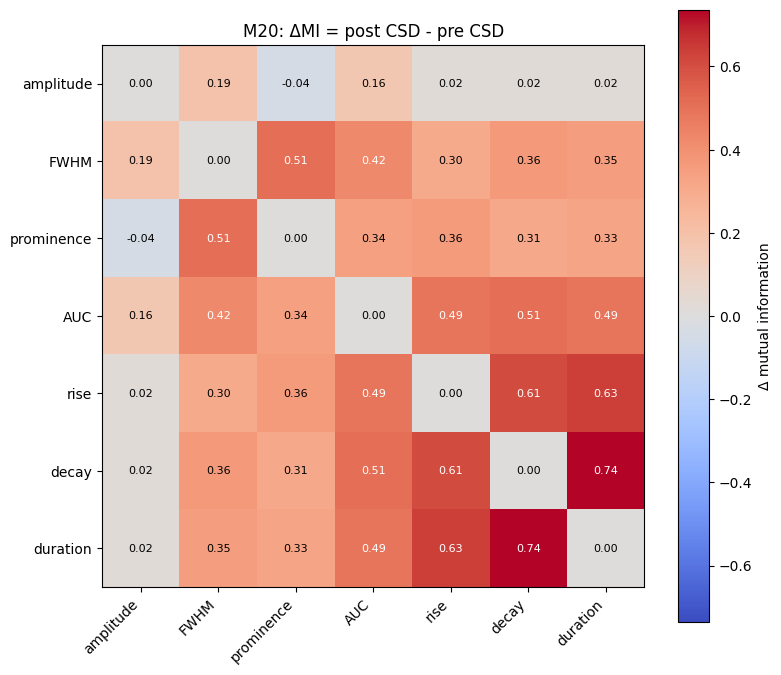

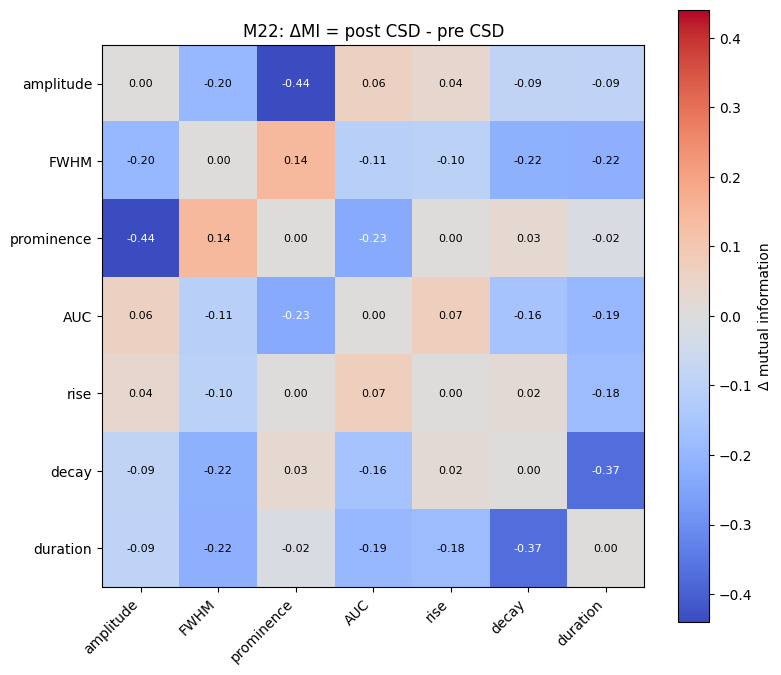

,animal,pre_block,post_block,feature_a,feature_b,pre_MI,post_MI,delta_MI_post_minus_pre
64,M18,M18_pre_CSD_Unknown,M18_post_CSD_Unknown,amplitude,prominence,0.040017,1.098019,1.058002
125,M20,M20_pre_CSD_Sham,M20_post_CSD_Sham,decay,duration,0.450000,1.186544,0.736544
65,M18,M18_pre_CSD_Unknown,M18_post_CSD_Unknown,amplitude,AUC,0.015198,0.673729,0.658531
124,M20,M20_pre_CSD_Sham,M20_post_CSD_Sham,rise,duration,0.450000,1.083980,0.633980
123,M20,M20_pre_CSD_Sham,M20_post_CSD_Sham,rise,decay,0.450000,1.058339,0.608339
101,M19,M19_pre_CSD_CCI,M19_post_CSD_CCI,AUC,duration,0.112477,0.709018,0.596541
74,M18,M18_pre_CSD_Unknown,M18_post_CSD_Unknown,prominence,AUC,0.058778,0.609736,0.550959
100,M19,M19_pre_CSD_CCI,M19_post_CSD_CCI,AUC,decay,0.058651,0.585590,0.526939
40,M15,M15_pre_CSD_Sham,M15_post_CSD_Sham,rise,duration,0.335802,0.856431,0.520629
121,M20,M20_pre_CSD_Sham,M20_post_CSD_Sham,AUC,decay,0.408333,0.916489,0.508156


,animal,pre_block,post_block,feature_a,feature_b,pre_MI,post_MI,delta_MI_post_minus_pre
127,M22,M22_pre_CSD_Sham,M22_post_CSD_Sham,amplitude,prominence,0.524215,0.083514,-0.440701
81,M18,M18_pre_CSD_Unknown,M18_post_CSD_Unknown,rise,decay,0.773726,0.356299,-0.417427
102,M19,M19_pre_CSD_CCI,M19_post_CSD_CCI,rise,decay,1.210659,0.824566,-0.386093
146,M22,M22_pre_CSD_Sham,M22_post_CSD_Sham,decay,duration,1.064863,0.694120,-0.370743
86,M19,M19_pre_CSD_CCI,M19_post_CSD_CCI,amplitude,AUC,0.385985,0.035253,-0.350732
69,M18,M18_pre_CSD_Unknown,M18_post_CSD_Unknown,FWHM,prominence,0.431196,0.166643,-0.264553
95,M19,M19_pre_CSD_CCI,M19_post_CSD_CCI,prominence,AUC,0.261860,0.000000,-0.261860
31,M15,M15_pre_CSD_Sham,M15_post_CSD_Sham,FWHM,duration,0.291455,0.032453,-0.259002
85,M19,M19_pre_CSD_CCI,M19_post_CSD_CCI,amplitude,prominence,0.711209,0.466754,-0.244456
44,M16,M16_pre_CSD_CCI,M16_post_CSD_CCI,amplitude,AUC,0.511609,0.270398,-0.241211


In [7]:
delta_rows = []

for animal in sorted(events["animal"].dropna().unique()):

    animal_blocks = [
        name for name in mi_matrices.keys()
        if name.startswith(f"{animal}_")
    ]

    pre_blocks = [
        name for name in animal_blocks
        if "_pre_CSD_" in name
    ]

    post_blocks = [
        name for name in animal_blocks
        if "_post_CSD_" in name
    ]

    if len(pre_blocks) == 0 or len(post_blocks) == 0:
        continue

    pre_block = pre_blocks[0]
    post_block = post_blocks[0]

    pre_mi = mi_matrices[pre_block]
    post_mi = mi_matrices[post_block]

    delta_mi = post_mi - pre_mi

    delta_mi.to_csv(
        matrix_dir / f"{animal}_post_minus_pre_delta_MI.csv"
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    max_abs = np.nanmax(np.abs(delta_mi.values))

    im = ax.imshow(
        delta_mi.values,
        cmap="coolwarm",
        vmin=-max_abs,
        vmax=max_abs
    )

    ax.set_xticks(np.arange(len(delta_mi.columns)))
    ax.set_yticks(np.arange(len(delta_mi.index)))

    ax.set_xticklabels(
        delta_mi.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(delta_mi.index)

    for i in range(delta_mi.shape[0]):
        for j in range(delta_mi.shape[1]):

            value = delta_mi.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(value) > max_abs / 2 else "black"
            )

    ax.set_title(f"{animal}: ΔMI = post CSD - pre CSD")

    fig.colorbar(
        im,
        ax=ax,
        label="Δ mutual information"
    )

    plt.tight_layout()

    fig.savefig(
        fig_dir / f"{animal}_post_minus_pre_delta_MI_heatmap.tiff",
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    for i, feature_a in enumerate(feature_cols):
        for j, feature_b in enumerate(feature_cols):

            if j <= i:
                continue

            delta_rows.append({
                "animal": animal,
                "pre_block": pre_block,
                "post_block": post_block,
                "feature_a": feature_a,
                "feature_b": feature_b,
                "pre_MI": pre_mi.loc[feature_a, feature_b],
                "post_MI": post_mi.loc[feature_a, feature_b],
                "delta_MI_post_minus_pre": delta_mi.loc[feature_a, feature_b]
            })

delta_summary = pd.DataFrame(delta_rows)

delta_summary.to_csv(
    output_dir / "pre_post_delta_mutual_information_summary.csv",
    index=False
)

display(
    delta_summary
    .sort_values("delta_MI_post_minus_pre", ascending=False)
    .head(20)
)

display(
    delta_summary
    .sort_values("delta_MI_post_minus_pre", ascending=True)
    .head(20)
)

,feature_a,feature_b,mean,std,count
14,decay,duration,1.039378,0.337405,14
20,rise,duration,1.023886,0.347230,14
19,rise,decay,0.609722,0.352337,14
1,AUC,duration,0.424118,0.228058,14
0,AUC,decay,0.383577,0.201107,14
6,FWHM,prominence,0.371345,0.223585,14
12,amplitude,prominence,0.369365,0.296178,14
2,AUC,rise,0.322204,0.213717,14
8,amplitude,AUC,0.320621,0.234214,14
15,prominence,AUC,0.190303,0.171605,14


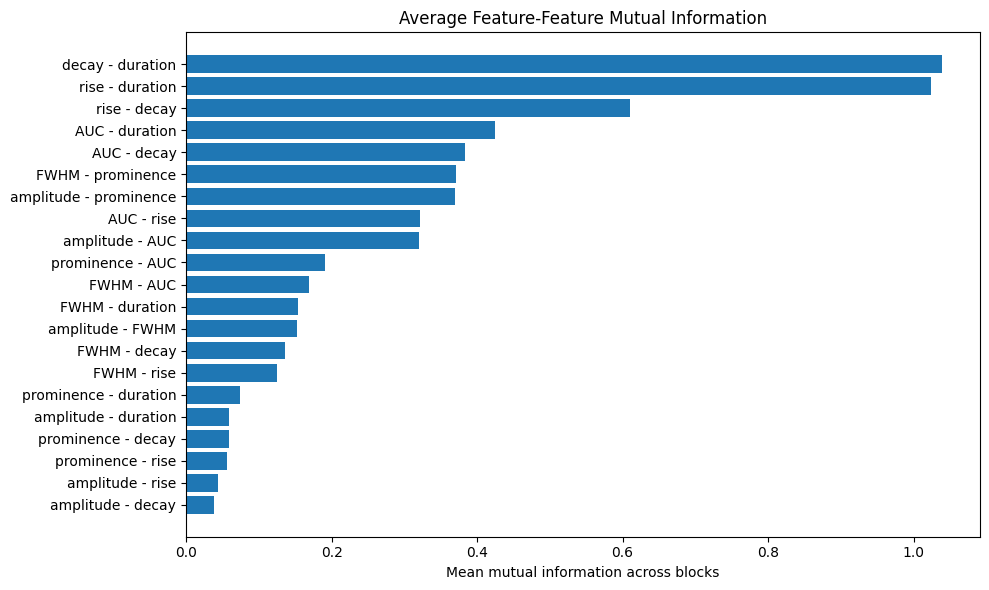

In [8]:
mean_pairwise_mi = (
    mi_summary
    .groupby(["feature_a", "feature_b"])["mutual_information"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

mean_pairwise_mi.to_csv(
    output_dir / "mean_pairwise_mutual_information_across_blocks.csv",
    index=False
)

display(mean_pairwise_mi)

plt.figure(figsize=(10, 6))

labels = (
    mean_pairwise_mi["feature_a"]
    + " - "
    + mean_pairwise_mi["feature_b"]
)

plt.barh(
    labels[::-1],
    mean_pairwise_mi["mean"].values[::-1]
)

plt.xlabel("Mean mutual information across blocks")
plt.title("Average Feature-Feature Mutual Information")
plt.tight_layout()

plt.savefig(
    fig_dir / "mean_pairwise_mutual_information_barplot.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.show()

,feature_a,feature_b,mean,std,count
1,AUC,duration,0.224540,0.269941,7
2,AUC,rise,0.150755,0.209900,7
20,rise,duration,0.134460,0.326562,7
12,amplitude,prominence,0.131326,0.497940,7
0,AUC,decay,0.130106,0.276058,7
6,FWHM,prominence,0.128352,0.266805,7
8,amplitude,AUC,0.097727,0.336187,7
7,FWHM,rise,0.085081,0.168181,7
15,prominence,AUC,0.084889,0.297793,7
17,prominence,duration,0.073654,0.132049,7


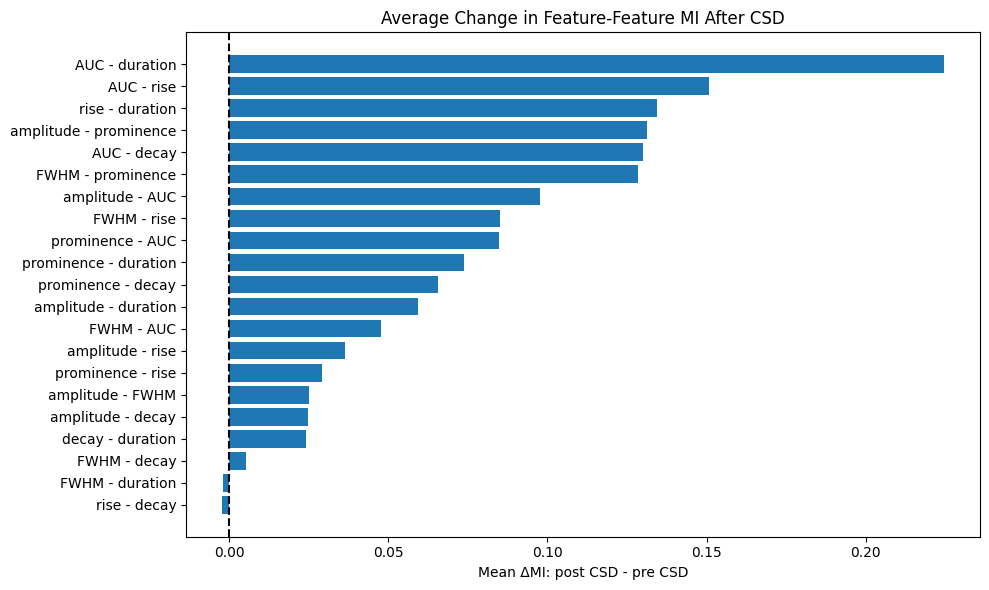

In [9]:
if len(delta_summary) > 0:

    mean_delta = (
        delta_summary
        .groupby(["feature_a", "feature_b"])["delta_MI_post_minus_pre"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    mean_delta.to_csv(
        output_dir / "mean_delta_MI_post_minus_pre_across_animals.csv",
        index=False
    )

    display(mean_delta)

    plt.figure(figsize=(10, 6))

    labels = (
        mean_delta["feature_a"]
        + " - "
        + mean_delta["feature_b"]
    )

    plt.barh(
        labels[::-1],
        mean_delta["mean"].values[::-1]
    )

    plt.axvline(0, linestyle="--", color="black")

    plt.xlabel("Mean ΔMI: post CSD - pre CSD")
    plt.title("Average Change in Feature-Feature MI After CSD")
    plt.tight_layout()

    plt.savefig(
        fig_dir / "mean_delta_MI_post_minus_pre_barplot.tiff",
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    plt.show()

else:
    print("No paired pre/post animals were available.")

## Interpretation

High MI between two waveform features means that knowing one feature reduces uncertainty about the other.

Examples:

- High `amplitude ↔ AUC`: larger amplitude events tend to carry information about total event area.
- High `duration ↔ decay`: event duration is strongly tied to decay kinetics.
- Positive post-minus-pre ΔMI: that dependency strengthened after CSD.
- Negative post-minus-pre ΔMI: that dependency weakened after CSD.

Important limitation:

Mutual information detects dependence, including nonlinear dependence, but it does not prove causation or direction.